# core

> A transparent, concise machine learning framework in JAX inspired by `miniai` from `fastai/course22p2` and optimized for efficient TPU usage.

In [ ]:
#| default_exp core

In [ ]:
#| hide
from nbdev.showdoc import *

In [ ]:
#| export
import jax
import jax.numpy as jnp
import time
from jax import random
from jax.sharding import Mesh, NamedSharding, PartitionSpec as P
random_key = jax.random.key(42)

import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import torchmetrics.functional as tmf

import matplotlib as mpl
import matplotlib.pyplot as plt

import optax
from operator import attrgetter
from functools import partial

## Visualization Functions

In [ ]:
def chunks(x, sz):
  for i in range(0, len(x), sz): yield x[i:i+sz]

def show_data(fashion_image, label=None, is_1d=False):
    if isinstance(fashion_image, tuple):
        fig, ax = plt.subplots(1, len(fashion_image), figsize=(9, 3))
        for i, x in enumerate(fashion_image):
            ax[i].imshow(x)
            ax[i].axis('off');
        plt.show()
    else:
        mpl.rcParams['image.cmap'] = 'gray'
        if label is not None:
            plt.title(f"{idx_to_class[label.item()]}")
        if is_1d==True:
            plt.imshow(list(chunks(fashion_image, 28)));
        else:
            plt.imshow(fashion_image);
        plt.axis('off');

## Load Fashion-MNIST

In [ ]:
train_data = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
test_data = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transforms.ToTensor())
x_train_all = train_data.data[:, None, :, :]/255
y_train_all = train_data.targets

rand_idx = torch.randperm(x_train_all.shape[0])
x_train = x_train_all[rand_idx[:50_000]]
train_mean = x_train.mean()
train_std = x_train.std()

x_train = jnp.array((x_train - train_mean) / train_std)
y_train = jnp.array(y_train_all[rand_idx[:50_000]])
x_valid = jnp.array((x_train_all[rand_idx[50_000:]] - train_mean) / train_std)
y_valid = jnp.array(y_train_all[rand_idx[50_000:]])
x_test = jnp.array((test_data.data[:, None, :, :]/255 - train_mean) / train_std)
y_test = jnp.array(test_data.targets)

x_train.shape, y_train.shape, x_valid.shape, y_valid.shape, x_test.shape, y_test.shape,

((50000, 1, 28, 28),
 (50000,),
 (10000, 1, 28, 28),
 (10000,),
 (10000, 1, 28, 28),
 (10000,))

In [ ]:
idx_to_class = {value: key for key, value in train_data.class_to_idx.items()}
num_classes = len(idx_to_class)
idx_to_class, num_classes

({0: 'T-shirt/top',
  1: 'Trouser',
  2: 'Pullover',
  3: 'Dress',
  4: 'Coat',
  5: 'Sandal',
  6: 'Shirt',
  7: 'Sneaker',
  8: 'Bag',
  9: 'Ankle boot'},
 10)

## DataLoaders

In [ ]:
#| export
class Dataset():
    "Combines features and lables in a dataset."
    def __init__(self, x, y): self.x, self.y = x, y
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i], self.y[i]

In [ ]:
train_ds = Dataset(x_train, y_train)
valid_ds = Dataset(x_valid, y_valid)
test_ds = Dataset(x_test, y_test)

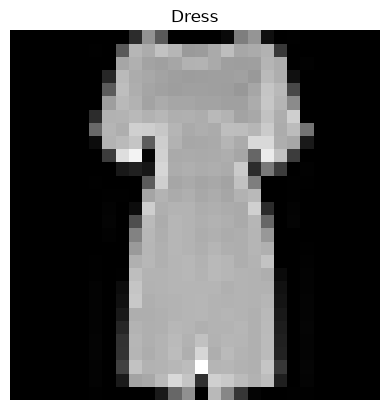

In [ ]:
show_data(x_train[0].squeeze(), y_train[0])

In [ ]:
#| export
class DataLoader():
    "Returns iterable batches from a dataset"
    def __init__(self, dataset, batch_size=32, drop_last=False, shuffle=True, random_key=jax.random.key(42)): 
        self.dataset = dataset
        self.batch_size = batch_size
        self.dataset_length = len(dataset)
        self.drop_last = drop_last
        self.key = random_key
        self.shuffle = shuffle

    def _loop_condition(self, batch_start):
        if self.drop_last:
            return batch_start + self.batch_size <= self.dataset_length
        else:
            return batch_start < self.dataset_length

    def __len__(self):
        if self.drop_last:
            return int(self.dataset_length // self.batch_size)
        else:
            return int(jnp.ceil(self.dataset_length / self.batch_size))

    def __iter__(self):
        batch_start = 0
        if self.shuffle:
            self.key, epoch_key = random.split(self.key)
            idxs = jax.random.permutation(epoch_key, self.dataset_length)
        else:
            idxs = jnp.arange(self.dataset_length)
        while self._loop_condition(batch_start):
            batch_idxs = idxs[batch_start: batch_start + self.batch_size] 
            x, y = self.dataset[batch_idxs]
            batch_start += self.batch_size
            yield x, y

In [ ]:
test_train_ds = Dataset(x_train[:-1], y_train[:-1])

In [ ]:
test_dataloader = DataLoader(test_train_ds, batch_size = 2)
test_generator = iter(test_dataloader)
next(test_generator)

(Array([[[[-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          ...,
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199]]],
 
 
        [[[-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          ...,
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,


In [ ]:
len(test_dataloader)

25000

In [ ]:
test_dataloader = DataLoader(test_train_ds, batch_size = 2, drop_last=True)
test_generator = iter(test_dataloader)
next(test_generator)

(Array([[[[-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          ...,
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199]]],
 
 
        [[[-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,
           -0.8108199, -0.8108199],
          ...,
          [-0.8108199, -0.8108199, -0.8108199, ..., -0.8108199,


In [ ]:
len(test_dataloader)

24999

In [ ]:
bs = 32

train_dl = DataLoader(train_ds, batch_size=bs, shuffle=True)
valid_dl = DataLoader(valid_ds, batch_size=bs, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=bs, shuffle=False)

In [ ]:
#| export
class DataLoaders():
    "Combines training and validation data in a DataLoaders object that can be passed to a learner."
    def __init__(self, *dls): self.train, self.valid = dls[:2]

In [ ]:
dls = DataLoaders(train_dl, valid_dl)
dls.train, dls.valid

(<__main__.DataLoader>,
 <__main__.DataLoader>)

In [ ]:
one_batch = next(iter(dls.train))[0]
one_batch.shape

(32, 1, 28, 28)

## Learner and Callbacks

In [ ]:
#| export
class CancelFitException(Exception): pass
class CancelBatchException(Exception): pass
class CancelEpochException(Exception): pass

In [ ]:
#| export
class with_cbs:
    def __init__(self, nm): self.nm = nm
    def __call__(self, f):
        def _f(o, *args, **kwargs):
            try:
                o.callback(f'before_{self.nm}')
                f(o, *args, **kwargs)
                o.callback(f'after_{self.nm}')
            except globals()[f'Cancel{self.nm.title()}Exception']: pass
            finally: o.callback(f'cleanup_{self.nm}')
        return _f

In [ ]:
#| export
def run_cbs(cbs, method_nm, learn=None):
    for cb in sorted(cbs, key=attrgetter('order')):
        method = getattr(cb, method_nm, None)
        if method is not None: method(learn)

In [ ]:
#| export
class Learner():
    def __init__(self, model, params, dls=(0,), loss_func=optax.softmax_cross_entropy_with_integer_labels, lr=0.001, cbs=None, opt=optax.sgd):
        self._model = model
        self.params = params
        self.dls = dls
        self._loss_func = loss_func
        self.lr = lr
        self.cbs = [] if cbs is None else list(cbs)
        self.opt = optax.inject_hyperparams(opt)(learning_rate=lr)
        self.opt_state = self.opt.init(params)
        self.metric_fns = []
        self.metrics_results = []
        
    @partial(jax.jit, static_argnums=(0,))
    def _train_step(self, params, x, y, opt_state, lr):
        def model_loss(params, x, y):
            y_pred = self._model(params, x)
            loss = self._loss_func(y_pred, y)
            return jnp.mean(loss), y_pred
        (loss, y_pred), grads = jax.value_and_grad(model_loss, has_aux=True)(params, x, y)
        opt_state = optax.tree_utils.tree_set(opt_state, learning_rate=lr)
        updates, opt_state = self.opt.update(grads, opt_state, params)
        updated_params = optax.apply_updates(params, updates)
        metrics_results = []
        for metric_fn in self.metric_fns: metrics_results.append(metric_fn(y_pred, y))
        return loss, updated_params, y_pred, opt_state, metrics_results
    
    @partial(jax.jit, static_argnums=(0,))
    def _eval_step(self, params, x, y):
        y_pred = self._model(params, x)
        loss = jnp.mean(self._loss_func(y_pred, y))
        metrics_results = []
        for metric_fn in self.metric_fns: metrics_results.append(metric_fn(y_pred, y))
        return loss, y_pred, metrics_results

    @with_cbs('batch')
    def _one_batch(self):
        if self.training:
            self.loss, self.params, self.preds, self.opt_state, self.metrics_results = self._train_step(self.params, self.batch[0], self.batch[1], self.opt_state, self.dyn_lr)
            self.callback('after_loss')
        else:
            self.loss, self.preds, self.metrics_results = self._eval_step(self.params, self.batch[0], self.batch[1])
            self.callback('after_loss')

    @with_cbs('epoch')
    def _one_epoch(self):
        for self.iter, self.batch in enumerate(self.dl): self._one_batch()

    def one_epoch(self, training):
        self.training = training
        self.dl = self.dls.train if training else self.dls.valid
        self._one_epoch()

    @with_cbs('fit')
    def _fit(self, train, valid):
        for self.epoch in self.epochs:
            if train: self.one_epoch(True)
            if valid: self.one_epoch(False)

    def fit(self, n_epochs=1, train=True, valid=True, cbs=None, lr=None):
        cbs = [] if cbs is None else list(cbs)
        for cb in cbs: self.cbs.append(cb)
        try:
            self.n_epochs = n_epochs
            self.epochs = range(n_epochs)
            if lr is None: lr = self.lr
            self.dyn_lr = jnp.float32(lr)
            self._fit(train, valid)
        finally:
            for cb in cbs: self.cbs.remove(cb)

    def callback(self, method_nm): run_cbs(self.cbs, method_nm, self)

In [ ]:
#| export
class Callback(): order = 0

In [ ]:
#| export
class DeviceParallelCB(Callback):
    order = -1
    def __init__(self, preload_data=False):
        self.preload_data = preload_data
    def before_fit(self, learn):
        mesh = Mesh(jax.devices(), ('batch',))
        self.data_sharding = NamedSharding(mesh, P())
        self.batch_sharding = NamedSharding(mesh, P('batch'))
        param_sharding = NamedSharding(mesh, P())
        learn.params = jax.device_put(learn.params, param_sharding)
        learn.opt_state = jax.device_put(learn.opt_state, param_sharding)
        if self.preload_data:
            learn.dls.train.dataset.x = jax.device_put(learn.dls.train.dataset.x, self.data_sharding)
            learn.dls.train.dataset.y = jax.device_put(learn.dls.train.dataset.y, self.data_sharding)
            learn.dls.valid.dataset.x = jax.device_put(learn.dls.valid.dataset.x, self.data_sharding)
            learn.dls.valid.dataset.y = jax.device_put(learn.dls.valid.dataset.y, self.data_sharding)
    def before_batch(self, learn):
        learn.batch = jax.device_put(learn.batch, self.batch_sharding)

In [ ]:
#| export
def accuracy(preds, targs):
    accuracy = (jnp.argmax(preds, axis=-1)==targs).astype(jnp.float32).sum()/preds.shape[0]
    return accuracy

In [ ]:
#| export
class MetricsCB(Callback):
    
    def __init__(self, *ms, **metrics):
        for m in ms: metrics[m.__name__] = m
        self.metrics = metrics
        self.values = {k: 0 for k in metrics.keys()}
        self.values['loss'] = 0
    
    def before_fit(self, learn):
        self.history = {f"Epoch {i}": {} for i in learn.epochs}
        learn.metric_fns = list(self.metrics.values())
    
    def after_loss(self, learn):
        self.values['loss'] += learn.loss/len(learn.dl)
        for i, m in enumerate(self.metrics):
            self.values[m] += learn.metrics_results[i]/len(learn.dl)
    
    def after_epoch(self, learn):
        if (learn.epoch == 0) & learn.training:
            print(f"{'Epoch':<8}" + "".join([f"{k:>12}" for k in self.values.keys()]) + f"{'Mode':>8}")
            print("-" * (8 + 12 * len(self.values.keys()) + 8))
        mode = "train" if learn.training else "eval"
        print(f"{learn.epoch:<8}" + "".join([f"{v.item():>12.4f}" for v in self.values.values()]) + f"{mode:>8}")
        self.history[f"Epoch {learn.epoch}"][f"{mode}"] = self.values.copy()
        self.values = {v:0 for v in self.values.keys()}

In [ ]:
#| export
class OneCycleCB(Callback):
    def __init__(self, pct_start=0.3, div=25, final_div=1e4):
        self.pct_start = pct_start
        self.div = div
        self.final_div = final_div
        
    def get_schedule(self, n_steps, pct_start, div, final_div, lr):
        n_x1 = int(jnp.ceil(n_steps * pct_start))
        up = jnp.arange(0, n_x1, 1)
        down = jnp.arange(n_x1, n_steps, 1) - n_x1
        x1 = (jnp.ones(up.shape[0]) * jnp.pi/up.shape[0]) * up
        x2 = (jnp.ones(down.shape[0]) * jnp.pi/down.shape[0]) * down
        y1 = (lr - lr/div)/2 * -jnp.cos(x1) + (lr + lr/div)/2
        y2 = (lr - lr/final_div)/2 * jnp.cos(x2) + (lr + lr/final_div)/2
        return jnp.concat((y1, y2))
        
    def before_fit(self, learn):
        self.n_steps = len(learn.dls.train)*learn.n_epochs
        self.sched = self.get_schedule(self.n_steps, self.pct_start, self.div, self.final_div, learn.lr)
        self.step_count = 0
        
    def before_batch(self, learn):
        if learn.training:
            learn.dyn_lr = self.sched[self.step_count]
            self.step_count += 1

In [ ]:
#| export
class LRRecorderCB(Callback):
    def __init__(self):
        self.step_count = 0
        self.steps = []
        self.lrs = []
    def after_batch(self, learn):
        if not learn.training: return
        self.steps.append(self.step_count)
        self.lrs.append(learn.dyn_lr)
        self.step_count += 1
    def plot(self):
        plt.figure(figsize=(5, 3))
        plt.plot(self.steps, self.lrs)
        plt.ylabel("learning rate")
        plt.xlabel("steps")
        plt.title("learning rates applied during training")
        plt.show()

In [ ]:
#| export
class LossRecorderCB(Callback):
    def __init__(self):
        self.step_count = 0
        self.steps = []
        self.train_losses = []
        self.valid_losses = []
        self.cumulative_valid_losses = []
    def before_fit(self, learn):
        self.valid_steps = [len(learn.dls.train) * (epoch + 1) for epoch in learn.epochs]
        self.cumulative_valid_losses = []
    def after_epoch(self, learn):
        if not learn.training:
            self.cumulative_valid_losses.append(jnp.array(self.valid_losses).mean())
            self.valid_losses = []
    def after_loss(self, learn):
        if learn.training:
            self.train_losses.append(learn.loss)
            self.steps.append(self.step_count)
            self.step_count += 1
        else:
            self.valid_losses.append(learn.loss)
    def plot(self):
        plt.figure(figsize=(5, 3))
        plt.plot(self.steps, self.train_losses, label="train loss")
        plt.plot(self.valid_steps, self.cumulative_valid_losses, label="valid loss")
        plt.ylabel("loss")
        plt.xlabel("steps")
        plt.title("loss curves")
        plt.legend()
        plt.show()

In [ ]:
#| export
class ProgressCB(ll.Callback):
    order = -2
    def __init__(self, n=50):
        self.n = n
    def before_fit(self, learn):
        import time; self.t = time
    def before_epoch(self, learn):
        self.epoch_start = self.t.time()
    def after_batch(self, learn):
        if learn.iter % self.n != 0: return
        total = len(learn.dl)
        elapsed = self.t.time() - self.epoch_start
        mode = "train" if learn.training else "eval"
        pct = 100 * learn.iter / total
        print(f"\r  {mode} {learn.iter:5d}/{total} ({pct:4.0f}%) {elapsed:6.0f}s  loss={learn.loss:.4f}",
              end="", flush=True)
    def after_epoch(self, learn):
        print()

## Advanced Model Factory

### Layer Functions

In [ ]:
#| export
def make_linear(key, fan_in, fan_out, act_fn=jax.nn.relu, initializer=jax.nn.initializers.he_normal, bias=True, act=True):
    init = initializer()
    params = {}
    params["w"] = init(key, (fan_in, fan_out), jnp.float32)
    if bias: params["b"] = jnp.zeros(fan_out)
    
    def lin_fn(params, x):
        x = x@params["w"]
        if bias: x += params["b"]
        if act: x = act_fn(x)
        return x
    
    return params, lin_fn

def make_conv2d(key, cho, chi, ks=(3, 3), padding='SAME', strides=(1, 1), act_fn=jax.nn.relu, initializer=jax.nn.initializers.he_normal, bias=True, act=True):
    init = initializer()
    params = {}
    params["w"] = init(key, (cho, chi, *ks), jnp.float32)
    if bias: params["b"] = jnp.zeros(cho)
    
    def conv2d_fn(params, x):
        x = jax.lax.conv_general_dilated(x, params["w"], padding=padding, window_strides=strides)
        if bias: x += params["b"][None, :, None, None]
        if act: x = act_fn(x)
        return x
    
    return params, conv2d_fn

def make_squeeze(key, dims=None):
    
    def squeeze(params, x): 
        if dims is None:
            return x.squeeze()
        return jnp.squeeze(x, axis=dims)
    
    return {}, squeeze

def make_layernorm2d(key, num_features, eps=1e-5, offset=True, ndims=4):
    broadcast_dims = tuple(None for i in range(ndims-2))
    axes = tuple(range(1, ndims))
    params = {}
    params["scale"] = jnp.ones(num_features)
    if offset: params["offset"] = jnp.zeros(num_features)
    
    def layernorm2d_fn(params, x):
        mean = jnp.mean(x, axis=axes)[:, None, *broadcast_dims]
        var = jnp.var(x, axis=axes)[:, None, *broadcast_dims]
        x_norm = (x - mean) / jnp.sqrt(var + eps)
        x = x_norm * params["scale"][None, :, *broadcast_dims]
        if offset: x += params["offset"][None, :, *broadcast_dims]
        return x
    
    return params, layernorm2d_fn

### Model Factory

In [ ]:
#| export
def make_model(key, model_dict, act_fn=jax.nn.relu, bias=True):
    
    all_params = {}
    funcs = {}
    keys = random.split(key, len(model_dict))
    for i, k in enumerate(model_dict.keys()):
        params, func = model_dict[k]['make_fn'](keys[i], *model_dict[k]['args'], **model_dict[k]['kwargs'])
        all_params[k] = params
        funcs[k] = func
    
    def model_fn(params, x):
        for k, f in funcs.items():
            x = f(params[k], x)
        return x
    
    return all_params, model_fn

In [ ]:
model_dict = {'Conv2d_1':    {'make_fn': make_conv2d,     'args': (8, 1),      'kwargs': {'strides': (2, 2), 'act': True}},
              'LayerNorm_1': {'make_fn': make_layernorm2d,  'args': (8,),         'kwargs': {'ndims': 4}},
              'Conv2d_2':    {'make_fn': make_conv2d,     'args': (16, 8),     'kwargs': {'strides': (2, 2), 'act': True}},
              'LayerNorm_2': {'make_fn': make_layernorm2d,  'args': (16,),         'kwargs': {'ndims': 4}},
              'Conv2d_3':    {'make_fn': make_conv2d,     'args': (32, 16),    'kwargs': {'padding': 'VALID', 'strides': (2, 2), 'act': True}},
              'LayerNorm_3': {'make_fn': make_layernorm2d,  'args': (32,),         'kwargs': {'ndims': 4}},
              'Conv2d_4':    {'make_fn': make_conv2d,     'args': (64, 32),    'kwargs': {'padding': 'VALID', 'strides': (1, 1), 'act': True}},
              'LayerNorm_4': {'make_fn': make_layernorm2d,  'args': (64,),         'kwargs': {'ndims': 4}},
              'Squeeze' :    {'make_fn': make_squeeze,    'args': (),          'kwargs': {'dims': (2, 3)}},
              'Linear_1':    {'make_fn': make_linear,     'args': (64, num_classes), 'kwargs': {'act': False}}}

In [ ]:
params, model = make_model(random_key, model_dict)

In [ ]:
sum(p.size for p in jax.tree_util.tree_leaves(params))

25274

In [ ]:
model(params, one_batch).shape

(32, 10)

## Training

In [ ]:
dls = DataLoaders(train_dl, valid_dl)
params, model = make_model(random_key, model_dict)
metrics = MetricsCB(accuracy)
lr_rec = LRRecorderCB()
loss_rec = LossRecorderCB()
cbs = [DeviceParallelCB(), OneCycleCB(), metrics, lr_rec, loss_rec]
learn = Learner(model, params, dls, loss_func=optax.softmax_cross_entropy_with_integer_labels, lr=0.01, cbs=cbs, opt=optax.adamw)

In [ ]:
learn.fit(5)

Epoch       accuracy        loss    Mode


----------------------------------------


0             0.8136      0.5246   train


0             0.8400      0.4363    eval


1             0.8671      0.3640   train


...

2             0.8876      0.3147    eval


3             0.9078      0.2482   train


3             0.9021      0.2663    eval


4             0.9287      0.1894   train


4             0.9114      0.2489    eval


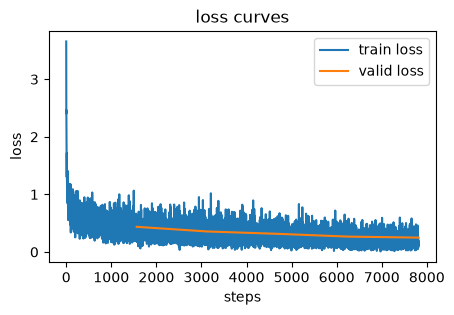

In [ ]:
loss_rec.plot()

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()